In [119]:
import pandas as pd
import numpy as np
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import svds
from sklearn.preprocessing import normalize
from sklearn.model_selection import train_test_split
import matplotlib.pyplot as plt

In [120]:
post_path = r"C:\Users\ADMIN\Desktop\ITDSIU21099_HoangVanManh\Fashion-Marketing-Automation-Solutions\data\processed\posts.csv"

In [121]:
df = pd.read_csv(post_path)
# Drop column caption, hashtags, and image
df = df.drop(columns=['caption', 'hashtags', 'image'])

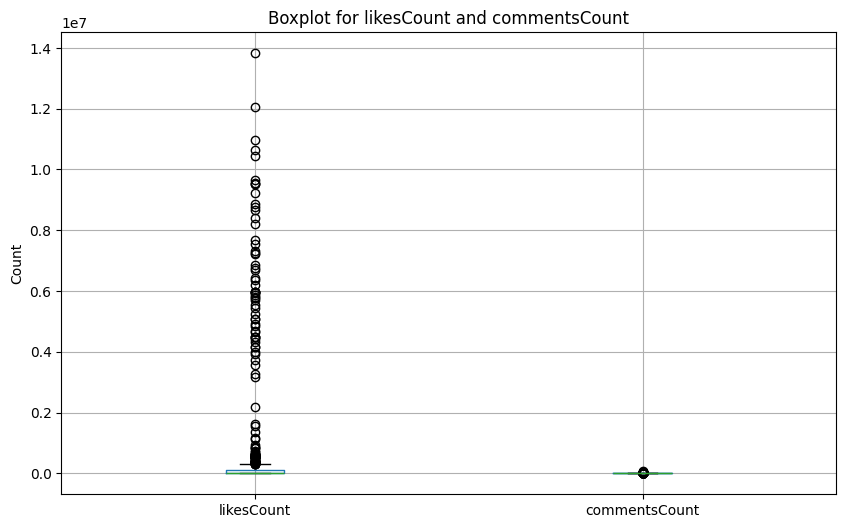

In [122]:
plt.figure(figsize=(10, 6))
df[['likesCount', 'commentsCount']].boxplot()
plt.title('Boxplot for likesCount and commentsCount')
plt.ylabel('Count')
plt.show()

In [123]:
print(df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 827 entries, 0 to 826
Data columns (total 5 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   post_id        827 non-null    int64 
 1   timestamp      827 non-null    object
 2   ownerUsername  827 non-null    object
 3   likesCount     827 non-null    int64 
 4   commentsCount  827 non-null    int64 
dtypes: int64(3), object(2)
memory usage: 32.4+ KB
None


In [124]:
df.rename(columns={'ownerUsername': 'user_id', 'post_id': 'outfit_id'}, inplace=True)   
df['interaction_score'] = np.log1p(df['likesCount']) + (3 * np.log1p(df['commentsCount']))
df.head()

,outfit_id,timestamp,user_id,likesCount,commentsCount,interaction_score
0,1,2023-06-02 16:34:43+00:00,maryleest,32070,142,25.264241
1,2,2023-01-01 07:49:16+00:00,tinaabeysekara,6565,86,22.187384
2,3,2023-05-29 18:57:51+00:00,maryleest,28936,123,24.733721
3,4,2023-03-07 19:30:42+00:00,stephaniebroek,4764,215,24.594888
4,5,2023-05-23 21:11:12+00:00,maryleest,13379,123,23.962361


In [125]:
train_df, test_df = train_test_split(df, test_size=0.2, random_state=42)

## Create Interaction Matrix

In [126]:
user_ids = df['user_id'].unique()
outfit_ids = df['outfit_id'].unique()

user_map = {user: i for i, user in enumerate(user_ids)}
outfit_map = {outfit: i for i, outfit in enumerate(outfit_ids)}

In [127]:
df['user_idx'] = df['user_id'].map(user_map)
df['outfit_idx'] = df['outfit_id'].map(outfit_map)

In [128]:
# Create a sparse interaction matrix
n_users = len(user_ids)
n_outfits = len(outfit_ids)

interaction_matrix = csr_matrix((df['interaction_score'], 
                                (df['user_idx'], df['outfit_idx'])), 
                                shape=(n_users, n_outfits))

reverse_user_map = {i: user for user, i in user_map.items()}
reverse_outfit_map = {i: outfit for outfit, i in outfit_map.items()}

### Implement SVD Matrix Factorization

In [129]:
interaction_matrix_dense = interaction_matrix.toarray()

# Center the data by subtracting row means
user_ratings_mean = np.mean(interaction_matrix_dense, axis=1)
interaction_matrix_centered = interaction_matrix_dense - user_ratings_mean.reshape(-1, 1)

# Apply SVD
U, sigma, Vt = svds(interaction_matrix_centered, k=20)

# Sort the results by singular values in descending order
idx = np.argsort(sigma)[::-1]
sigma = sigma[idx]
U = U[:, idx]
Vt = Vt[idx, :]

# Predictions matrix = user latent factors * singular values * outfit latent factors
predicted_ratings = U.dot(np.diag(sigma)).dot(Vt) + user_ratings_mean.reshape(-1, 1)

###  Custom implementation of SVD++

In [130]:
class CustomSVDPP:
    def __init__(self, n_factors=20, n_epochs=50, lr=0.005, reg=0.02):
        self.n_factors = n_factors
        self.n_epochs = n_epochs
        self.lr = lr
        self.reg = reg
        
    def fit(self, interaction_matrix):
        # Convert to array for easier processing
        R = interaction_matrix.toarray()
        n_users, n_items = R.shape    
        
        self.user_factors = np.random.normal(0, 0.1, (n_users, self.n_factors))
        self.item_factors = np.random.normal(0, 0.1, (n_items, self.n_factors))
        
        self.user_biases = np.zeros(n_users)
        # Item biases
        self.item_biases = np.zeros(n_items)
        # Global bias (mean of all ratings)
        self.global_bias = np.mean(R[R != 0])      
        
        self.implicit_factors = np.random.normal(0, 0.1, (n_items, self.n_factors))
        
        # Get user-item interactions
        self.user_items = {}
        for u in range(n_users):
            self.user_items[u] = np.where(R[u] > 0)[0]        
        
        # Initialize the matrices and parameters
        self.user_items = {}
        for u in range(n_users):
            self.user_items[u] = np.where(R[u] > 0)[0]
            
        for epoch in range(self.n_epochs):
            user_indices = np.arange(n_users)
            np.random.shuffle(user_indices)
            
            for u in user_indices:
                rated_items = np.where(R[u] > 0)[0]
                if len(rated_items) == 0:
                    continue
                
                # Precompute implicit feedback term
                if len(self.user_items[u]) > 0:
                    implicit_sum = np.sum(self.implicit_factors[self.user_items[u]], axis=0)
                    implicit_term = implicit_sum / np.sqrt(len(self.user_items[u]))
                else:
                    implicit_term = np.zeros(self.n_factors)
                
                # Update factors for each item rated by user u
                for i in rated_items:
                    # Predicted rating
                    pred = self.global_bias + self.user_biases[u] + self.item_biases[i] + \
                            np.dot(self.user_factors[u] + implicit_term, self.item_factors[i])
                    
                    # Error
                    err = R[u, i] - pred
                    
                    # Update biases
                    self.user_biases[u] += self.lr * (err - self.reg * self.user_biases[u])
                    self.item_biases[i] += self.lr * (err - self.reg * self.item_biases[i])
                    
                    # Update factors
                    user_factors_grad = err * self.item_factors[i] - self.reg * self.user_factors[u]
                    item_factors_grad = err * (self.user_factors[u] + implicit_term) - self.reg * self.item_factors[i]
                    
                    self.user_factors[u] += self.lr * user_factors_grad
                    self.item_factors[i] += self.lr * item_factors_grad
                    
                    # Update implicit factors for all items rated by user u
                    if len(self.user_items[u]) > 0:
                        # Fix: Calculate the gradient for each item separately
                        for idx, item_idx in enumerate(self.user_items[u]):
                            implicit_grad = err * self.item_factors[i] / np.sqrt(len(self.user_items[u])) - \
                                            self.reg * self.implicit_factors[item_idx]
                            self.implicit_factors[item_idx] += self.lr * implicit_grad
            
            if (epoch + 1) % 5 == 0:
                print(f"Epoch {epoch + 1}/{self.n_epochs} completed")
            
    def predict(self, user_idx, item_idx):
        """
        Predict the rating for a user-item pair.
        
        Args:
            user_idx: User index
            item_idx: Item index
            
        Returns:
            Predicted rating
        """
        # Calculate implicit feedback term
        if user_idx in self.user_items and len(self.user_items[user_idx]) > 0:
            implicit_sum = np.sum(self.implicit_factors[self.user_items[user_idx]], axis=0)
            implicit_term = implicit_sum / np.sqrt(len(self.user_items[user_idx]))
        else:
            implicit_term = np.zeros(self.n_factors)
        
        # Calculate prediction
        pred = self.global_bias + self.user_biases[user_idx] + self.item_biases[item_idx] + \
               np.dot(self.user_factors[user_idx] + implicit_term, self.item_factors[item_idx])
        
        return pred
    
    def predict_all(self):
        """
        Generate predictions for all user-item pairs.
        
        Returns:
            Matrix of predicted ratings
        """
        n_users, n_items = len(self.user_biases), len(self.item_biases)
        predictions = np.zeros((n_users, n_items))
        
        for u in range(n_users):
            # Calculate implicit feedback term
            if u in self.user_items and len(self.user_items[u]) > 0:
                implicit_sum = np.sum(self.implicit_factors[self.user_items[u]], axis=0)
                implicit_term = implicit_sum / np.sqrt(len(self.user_items[u]))
            else:
                implicit_term = np.zeros(self.n_factors)
                
            # Calculate all predictions for user u
            predictions[u] = self.global_bias + self.user_biases[u] + self.item_biases + \
                            np.dot(self.user_factors[u] + implicit_term, self.item_factors.T)
        
        return predictions

In [131]:
def evaluate_model(model, test_df, user_map, outfit_map):
    """
    Evaluate model performance.
    
    Args:
        model: Trained recommendation model
        test_df: Test data
        user_map: Mapping from user IDs to matrix indices
        outfit_map: Mapping from outfit IDs to matrix indices
        
    Returns:
        RMSE and MAE
    """
    predictions = []
    actuals = []
    
    for _, row in test_df.iterrows():
        user_id = row['user_id']
        outfit_id = row['outfit_id']
        
        if user_id in user_map and outfit_id in outfit_map:
            user_idx = user_map[user_id]
            outfit_idx = outfit_map[outfit_id]
            
            if isinstance(model, CustomSVDPP):
                pred = model.predict(user_idx, outfit_idx)
            else:
                # For SVD model (predicted_ratings from apply_svd function)
                pred = model[user_idx, outfit_idx]
                
            predictions.append(pred)
            actuals.append(row['interaction_score'])
    
    # Calculate metrics
    predictions = np.array(predictions)
    actuals = np.array(actuals)
    
    rmse = np.sqrt(np.mean((predictions - actuals) ** 2))
    mae = np.mean(np.abs(predictions - actuals))
    
    return rmse, mae

In [132]:
print("Evaluating SVD model...")
svd_rmse, svd_mae = evaluate_model(predicted_ratings, test_df, user_map, outfit_map)
print(f"SVD - RMSE: {svd_rmse:.4f}, MAE: {svd_mae:.4f}")

Evaluating SVD model...
SVD - RMSE: 7.6069, MAE: 3.5895


In [133]:
print("Implementing custom SVD++ algorithm...")
svdpp_model = CustomSVDPP(n_factors=20, n_epochs=50, lr=0.005, reg=0.02)
svdpp_model.fit(interaction_matrix)

print("Evaluating SVD++ model...")
svdpp_rmse, svdpp_mae = evaluate_model(svdpp_model, test_df, user_map, outfit_map)
print(f"SVD++ - RMSE: {svdpp_rmse:.4f}, MAE: {svdpp_mae:.4f}")

Implementing custom SVD++ algorithm...
Epoch 5/50 completed
Epoch 10/50 completed
Epoch 15/50 completed
Epoch 20/50 completed
Epoch 25/50 completed
Epoch 30/50 completed
Epoch 35/50 completed
Epoch 40/50 completed
Epoch 45/50 completed
Epoch 50/50 completed
Evaluating SVD++ model...
SVD++ - RMSE: 0.1801, MAE: 0.1023


### Generate outfit recommendations for a specific user

In [134]:
def generate_recommendations(user_id, model, df, user_map, outfit_map, reverse_outfit_map, top_n=10, type_of_model='svdpp'):
    """
    Generate outfit recommendations for a specific user.
    
    Args:
        user_id: ID of the user
        model: Trained recommendation model
        df: Preprocessed DataFrame with user-outfit interactions
        user_map: Mapping from user IDs to matrix indices
        outfit_map: Mapping from outfit IDs to matrix indices
        reverse_outfit_map: Mapping from matrix indices to outfit IDs
        top_n: Number of recommendations to generate
        type_of_model: Type of model ('svd' or 'svdpp')
        
    Returns:
        List of recommended outfits
    """
    if user_id not in user_map:
        return []
    
    user_idx = user_map[user_id]
    
    # Get all outfits
    all_outfits = list(outfit_map.keys())
    
    # Get outfits the user has already interacted with
    user_interactions = df[df['user_id'] == user_id]['outfit_id'].unique()
    
    # Find outfits the user hasn't interacted with
    new_outfits = [outfit for outfit in all_outfits if outfit not in user_interactions]
    
    # Generate predictions for new outfits
    predictions = []
    for outfit_id in new_outfits:
        outfit_idx = outfit_map[outfit_id]
        
        if type_of_model == 'svdpp':
            # For CustomSVDPP model
            predicted_score = model.predict(user_idx, outfit_idx)
        else:
            # For SVD predicted ratings matrix
            predicted_score = model[user_idx, outfit_idx]
            
        predictions.append((outfit_id, predicted_score))
    
    # Sort predictions by estimated score (descending)
    predictions.sort(key=lambda x: x[1], reverse=True)
    
    # Return top N recommendations
    return predictions[:top_n]


In [135]:
# Generate recommendations for a sample user
print("Generating outfit recommendations:")
sample_user = df['user_id'].iloc[0]

# Get recommendations using SVD
svd_recommendations = generate_recommendations(
    sample_user, predicted_ratings, df, user_map, outfit_map, 
    reverse_outfit_map, type_of_model='svd'
)

print(f"\nTop SVD recommendations for user {sample_user}:")
for i, (outfit_id, score) in enumerate(svd_recommendations):
    print(f"{i+1}. Outfit ID: {outfit_id}, Predicted Score: {score}")

Generating outfit recommendations:

Top SVD recommendations for user maryleest:
1. Outfit ID: 115, Predicted Score: 0.43139463302333403
2. Outfit ID: 116, Predicted Score: 0.43118730059955623
3. Outfit ID: 118, Predicted Score: 0.43093354622098506
4. Outfit ID: 143, Predicted Score: 0.43086015430699637
5. Outfit ID: 215, Predicted Score: 0.43086015430699637
6. Outfit ID: 128, Predicted Score: 0.430791213200948
7. Outfit ID: 148, Predicted Score: 0.430791213200948
8. Outfit ID: 123, Predicted Score: 0.4306647296357617
9. Outfit ID: 127, Predicted Score: 0.4306063999284252
10. Outfit ID: 120, Predicted Score: 0.43055091673065266


In [136]:
# Get recommendations using SVD++
svdpp_recommendations = generate_recommendations(
    sample_user, svdpp_model, df, user_map, outfit_map, 
    reverse_outfit_map, type_of_model='svdpp'
)

print(f"\nTop SVD++ recommendations for user {sample_user}:")
for i, (outfit_id, score) in enumerate(svdpp_recommendations):
    print(f"{i+1}. Outfit ID: {outfit_id}, Predicted Score: {score}")


Top SVD++ recommendations for user maryleest:
1. Outfit ID: 41, Predicted Score: 26.120727588999905
2. Outfit ID: 511, Predicted Score: 25.61856396365746
3. Outfit ID: 682, Predicted Score: 25.601620632088867
4. Outfit ID: 303, Predicted Score: 25.55515881592783
5. Outfit ID: 583, Predicted Score: 25.506553164127947
6. Outfit ID: 686, Predicted Score: 25.351785534710462
7. Outfit ID: 236, Predicted Score: 25.332713744654303
8. Outfit ID: 187, Predicted Score: 25.320326469736603
9. Outfit ID: 234, Predicted Score: 25.281498819416846
10. Outfit ID: 345, Predicted Score: 25.250289037163707


In [137]:
def analyze_latent_factors(U, Vt, sigma, top_n=5):
    # Normalize the factor matrices
    user_factors = normalize(U, axis=1)
    outfit_factors = normalize(Vt.T, axis=1)
    
    # Get the importance of each latent factor
    factor_importance = sigma / np.sum(sigma)
    
    # Plot the importance of latent factors
    plt.figure(figsize=(10, 6))
    plt.bar(range(len(sigma)), factor_importance)
    plt.xlabel('Latent Factor Index')
    plt.ylabel('Importance (% of Variance Explained)')
    plt.title('Importance of Latent Factors')
    plt.tight_layout()
    plt.show()
    
    # Identify the most influential users and outfits for each latent factor
    top_users = {}
    top_outfits = {}
    
    for i in range(min(top_n, len(sigma))):
        # Find users with highest values in this factor
        user_factor_values = user_factors[:, i]
        top_user_indices = np.argsort(user_factor_values)[-top_n:][::-1]
        top_users[i] = top_user_indices
        
        # Find outfits with highest values in this factor
        outfit_factor_values = outfit_factors[:, i]
        top_outfit_indices = np.argsort(outfit_factor_values)[-top_n:][::-1]
        top_outfits[i] = top_outfit_indices
    
    return factor_importance, top_users, top_outfits

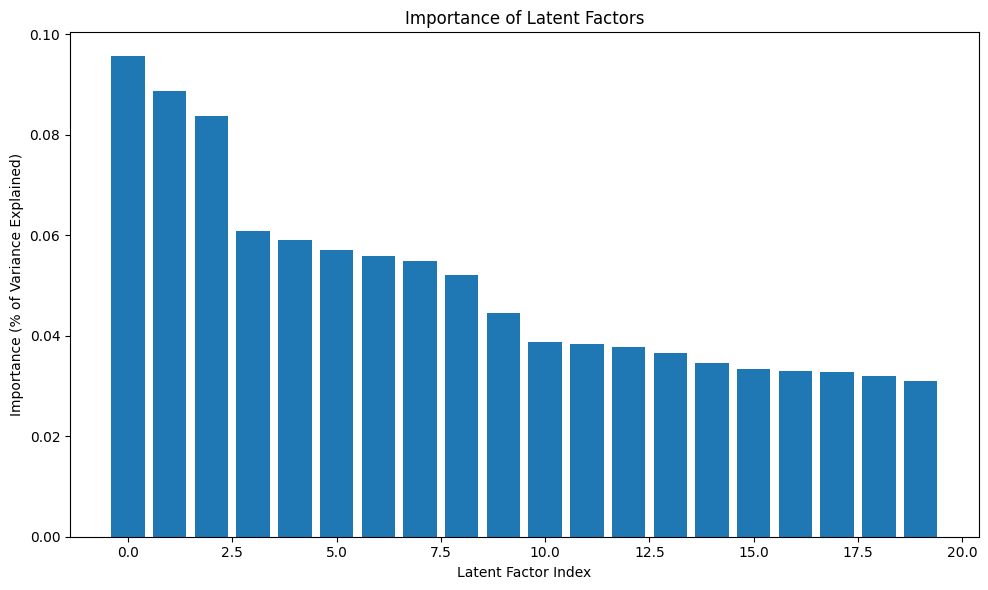

In [138]:
factor_importance, top_users, top_outfits = analyze_latent_factors(U, Vt, sigma)